# CDLE: Diagnóstico e Profiling de Performance em Big Data

Este notebook é dedicado exclusivamente ao **profiling de CPU** das operações mais exigentes do pipeline (**Value Counts** e **GroupBy**) nas 5 frameworks: **Pandas, Dask, PySpark, Modin e Joblib**.

Utiliza-se a magia do Jupyter `%%prun -s tottime -l 15` no topo de cada célula de computação para listar e ordenar as 15 funções internas que mais consomem tempo de CPU, permitindo analisar bottlenecks de forma isolada e económica no Dataproc.

In [1]:
import sys
!{sys.executable} -m pip install -q "modin[ray]" matplotlib

In [2]:
# --- PATCH GLOBAL DE VISUALIZAÇÃO DE TABELAS ---
import pandas as pd
if not hasattr(pd.Index, '_format_flat'):
    pd.Index._format_flat = lambda self, *args, **kwargs: [str(x) for x in self]

try:
    import pyspark.pandas as ps
    if not hasattr(ps.Index, '_format_flat'):
        ps.Index._format_flat = lambda self, *args, **kwargs: [str(x) for x in self]
except Exception:
    pass
# -----------------------------------------------

import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

/usr/lib/spark/python/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [3]:
print(" 1 - Escala Pequena (~123k linhas)")
print(" 2 - Escala Média (~2.46M linhas)")
print(" 3 - Escala Grande (~9M linhas)")

while True:
    try:
        op = input("Introduza a opcao desejada (1, 2 ou 3): ").strip()
        ESCALA_DATASET = int(op)
        if ESCALA_DATASET in [1, 2, 3]:
            break
        else:
            print("Opcao invalida. Por favor, introduza 1, 2 ou 3.")
    except ValueError:
        print("Entrada invalida. Por favor, introduza um numero.")

base_dir = "gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/"
caminho = {
    1: base_dir + "yellow_tripdata_2022_small.parquet",
    2: base_dir + "yellow_tripdata_2022-01.parquet",
    3: base_dir + "yellow_tripdata_2022_large.parquet"
}

file_path = caminho[ESCALA_DATASET]

pandas_results = {}
dask_results = {}
pyspark_results = {}
modin_results = {}
joblib_results = {}

 1 - Escala Pequena (~123k linhas)
 2 - Escala Média (~2.46M linhas)
 3 - Escala Grande (~9M linhas)


Introduza a opcao desejada (1, 2 ou 3):  2


---
## Secção 1: Profiling com Pandas

O Pandas executa em modo **eager** e single-thread. Espera-se que a maior parte do tempo de CPU seja despendida diretamente em funções internas compiladas do NumPy ou do interpretador C.

In [4]:
df_pd = pd.read_parquet(file_path)

## 1.1 Value Counts

In [5]:
%%prun -s tottime -l 15

import time
start = time.time()
vc_pd = df_pd['VendorID'].value_counts()
pandas_results['Value Counts'] = time.time() - start


         591 function calls (542 primitive calls) in 0.010 seconds

   Ordered by: internal time
   List reduced from 148 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.008    0.008    0.008    0.008 algorithms.py:963(value_counts_arraylike)
     21/2    0.000    0.000    0.000    0.000 {built-in method _abc._abc_subclasscheck}
        1    0.000    0.000    0.009    0.009 algorithms.py:862(value_counts_internal)
        1    0.000    0.000    0.010    0.010 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 sorting.py:369(nargsort)
        1    0.000    0.000    0.000    0.000 series.py:3706(sort_values)
        1    0.000    0.000    0.000    0.000 base.py:2320(is_unique)
  127/126    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        2    0.000    0.000    0.000    0.000 series.py:392(__init__)
        1    0.000    0.000    0.000    0.000 base.py:843(_engine

## 1.2 GroupBy

In [6]:
%%prun -s tottime -l 15

import time
start = time.time()
gb_pd = df_pd.groupby('payment_type')['fare_amount'].mean()
pandas_results['GroupBy'] = time.time() - start

         619 function calls (613 primitive calls) in 0.034 seconds

   Ordered by: internal time
   List reduced from 220 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.013    0.013    0.013    0.013 algorithms.py:548(factorize_array)
        1    0.011    0.011    0.011    0.011 ops.py:358(_call_cython_op)
        1    0.007    0.007    0.007    0.007 take.py:120(_take_nd_ndarray)
        1    0.002    0.002    0.022    0.022 ops.py:744(has_dropped_na)
        1    0.000    0.000    0.020    0.020 algorithms.py:610(factorize)
        1    0.000    0.000    0.000    0.000 {method 'reduce' of 'numpy.ufunc' objects}
        1    0.000    0.000    0.034    0.034 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 grouper.py:846(get_grouper)
        1    0.000    0.000    0.034    0.034 {built-in method builtins.exec}
  105/104    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
    

Para limpar a memória, para evitar qualquer tipo de crash dos clusters.

In [7]:
import gc
del df_pd, vc_pd, gb_pd
gc.collect()

0

---
## Secção 2: Profiling com Dask

O Dask constrói um grafo de tarefas e executa-as em chunks. O profiling revelará o tempo de coordenação do agendador síncrono e a concatenação dos pedaços intermédios.

In [8]:
# Patch de compatibilidade Dask e Python 3.11
try:
    import dask.utils
    original_derived_from = dask.utils.derived_from
    def safe_derived_from(*args, **kwargs):
        decorator = original_derived_from(*args, **kwargs)
        def safe_decorator(func):
            try:
                return decorator(func)
            except Exception:
                return func
        return safe_decorator
    dask.utils.derived_from = safe_derived_from
    import dask
    dask.config.set(scheduler='synchronous')
except Exception as e:
    print(f"Aviso Dask patch: {e}")

import dask.dataframe as dd

df_dd = dd.read_parquet(file_path)

## 2.1 Value Count

In [9]:
%%prun -s tottime -l 15

import time
start = time.time()
vc_dd = df_dd['VendorID'].value_counts().compute()
dask_results['Value Counts'] = time.time() - start

         214276 function calls (208854 primitive calls) in 0.331 seconds

   Ordered by: internal time
   List reduced from 2296 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.092    0.092    0.093    0.093 core.py:580(read)
       12    0.042    0.004    0.042    0.004 {method 'acquire' of '_thread.lock' objects}
      157    0.017    0.000    0.017    0.000 {built-in method marshal.loads}
        7    0.013    0.002    0.013    0.002 take.py:120(_take_nd_ndarray)
    311/1    0.010    0.000    0.331    0.331 {built-in method builtins.exec}
    12196    0.009    0.000    0.009    0.000 reader.py:99(forward)
        2    0.008    0.004    0.008    0.004 algorithms.py:963(value_counts_arraylike)
  543/542    0.006    0.000    0.028    0.000 {built-in method builtins.__build_class__}
        1    0.005    0.005    0.005    0.005 pandas_compat.py:755(table_to_dataframe)
      620    0.005    0.000    0.014    0.000 sca

## 2.2 GroupBy

In [10]:
%%prun -s tottime -l 15

import time
start = time.time()
gb_dd = df_dd.groupby('payment_type')['fare_amount'].mean().compute()
dask_results['GroupBy'] = time.time() - start

         20183 function calls (19647 primitive calls) in 0.288 seconds

   Ordered by: internal time
   List reduced from 1117 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.130    0.130    0.130    0.130 core.py:580(read)
       20    0.044    0.002    0.044    0.002 {method 'acquire' of '_thread.lock' objects}
       20    0.040    0.002    0.040    0.002 take.py:120(_take_nd_ndarray)
        6    0.021    0.003    0.021    0.004 algorithms.py:548(factorize_array)
        1    0.012    0.012    0.012    0.012 pandas_compat.py:755(table_to_dataframe)
        4    0.011    0.003    0.012    0.003 ops.py:358(_call_cython_op)
        2    0.006    0.003    0.007    0.004 groupby.py:2336(hfunc)
        4    0.002    0.000    0.017    0.004 ops.py:744(has_dropped_na)
        4    0.002    0.000    0.002    0.000 missing.py:261(_isna_array)
        2    0.001    0.001    0.024    0.012 groupby.py:2271(count)
       45   

Para limpar a memória, para evitar qualquer tipo de crash dos clusters

In [11]:
import gc
del df_dd, vc_dd, gb_dd
gc.collect()

0

---
## Secção 3: Profiling com PySpark (Koalas)

No PySpark, a computação real ocorre na JVM (Java Virtual Machine). O profiling do Python mostrará predominantemente chamadas de sockets, comunicação via rede, e serialização de dados através do protocolo Py4J.

In [12]:
import os
os.environ['PYARROW_IGNORE_TIMEZONE'] = '1'
from pyspark.sql import SparkSession
import pyspark.pandas as ps

spark = SparkSession.builder \
    .appName('CDLE-Profiling') \
    .config('spark.sql.ansi.enabled', 'false') \
    .getOrCreate()

sdf = spark.read.parquet(file_path)
for col_name, col_type in sdf.dtypes:
    if 'timestamp' in col_type or 'ntz' in col_type.lower():
        sdf = sdf.withColumn(col_name, sdf[col_name].cast('timestamp'))

df_ps = sdf.to_pandas_on_spark()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 00:19:40 INFO SparkEnv: Registering MapOutputTracker
26/06/01 00:19:40 INFO SparkEnv: Registering BlockManagerMaster
26/06/01 00:19:40 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/06/01 00:19:40 INFO SparkEnv: Registering OutputCommitCoordinator
/usr/lib/spark/python/pyspark/sql/dataframe.py:5725: FutureWarning: DataFrame.to_pandas_on_spark is deprecated. Use DataFrame.pandas_api instead.
  warnings.warn(


## 3.1 Value Counts

In [13]:
%%prun -s tottime -l 15

import time
start = time.time()
vc_ps = df_ps['VendorID'].value_counts()
pyspark_results['Value Counts'] = time.time() - start


/usr/lib/spark/python/pyspark/pandas/base.py:1437: FutureWarning: The resulting Series will have a fixed name of 'count' from 4.0.0.
  warnings.warn(


         7270 function calls (7178 primitive calls) in 0.128 seconds

   Ordered by: internal time
   List reduced from 319 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       57    0.117    0.002    0.117    0.002 {method 'recv_into' of '_socket.socket' objects}
       57    0.001    0.000    0.001    0.000 {method 'sendall' of '_socket.socket' objects}
       57    0.001    0.000    0.119    0.002 clientserver.py:499(send_command)
       18    0.000    0.000    0.001    0.000 typehints.py:139(as_spark_type)
      233    0.000    0.000    0.000    0.000 protocol.py:214(smart_decode)
       38    0.000    0.000    0.001    0.000 java_gateway.py:1283(<listcomp>)
     1289    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
       59    0.000    0.000    0.117    0.002 {method 'readline' of '_io.BufferedReader' objects}
       28    0.000    0.000    0.001    0.000 java_gateway.py:1336(__init__)
        1    

## 3.2 GroupBy

In [14]:
%%prun -s tottime -l 15

import time
start = time.time()
gb_ps = df_ps.groupby('payment_type')['fare_amount'].mean()
pyspark_results['GroupBy'] = time.time() - start


/usr/lib/spark/python/pyspark/pandas/groupby.py:649: FutureWarning: Default value of `numeric_only` will be changed to `False` instead of `True` in 4.0.0.
  warnings.warn(


         19802 function calls (19522 primitive calls) in 0.092 seconds

   Ordered by: internal time
   List reduced from 491 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      106    0.070    0.001    0.070    0.001 {method 'recv_into' of '_socket.socket' objects}
       84    0.001    0.000    0.003    0.000 typehints.py:139(as_spark_type)
      106    0.001    0.000    0.001    0.000 {method 'sendall' of '_socket.socket' objects}
      106    0.001    0.000    0.073    0.001 clientserver.py:499(send_command)
       10    0.001    0.000    0.001    0.000 {built-in method marshal.loads}
      237    0.000    0.000    0.001    0.000 protocol.py:214(smart_decode)
     2509    0.000    0.000    0.001    0.000 {built-in method builtins.isinstance}
       23    0.000    0.000    0.034    0.001 internal.py:540(__init__)
        1    0.000    0.000    0.000    0.000 {method 'readlines' of '_io._IOBase' objects}
      169    0.000    0

In [15]:
import gc
spark.stop()
del df_ps, vc_ps, gb_ps
gc.collect()

297

---
## Secção 4: Profiling com Modin

O Modin abstrai a distribuição do Pandas. Ao correr com o engine em modo python/single-process para evitar picos de memória, o profiling revelará os wrappers de metadados e distribuição criados pelo Modin.

In [16]:
import os
os.environ["MODIN_ENGINE"] = "python"

# Patch de compatibilidade com Pandas 2.1.4
import sys
import pandas as pd
try:
    import pandas.core.arrays.arrow
except ImportError:
    import types
    sys.modules['pandas.core.arrays.arrow'] = types.ModuleType('pandas.core.arrays.arrow')
    import pandas.core.arrays.arrow

if not hasattr(pandas.core.arrays.arrow, 'ListAccessor'):
    class DummyListAccessor: pass
    pandas.core.arrays.arrow.ListAccessor = DummyListAccessor

if not hasattr(pandas.core.arrays.arrow, 'StructAccessor'):
    class DummyStructAccessor: pass
    pandas.core.arrays.arrow.StructAccessor = DummyStructAccessor

import modin.pandas as mpd

df_mod = mpd.read_parquet(file_path)

Please refer to https://modin.readthedocs.io/en/stable/supported_apis/defaulting_to_pandas.html for explanation.


## 4.1 Value Counts

In [17]:
%%prun -s tottime -l 15

import time
start = time.time()
val_mod = df_mod['VendorID'].value_counts()
modin_results['Value Counts'] = time.time() - start

the groupby keys will be sorted anyway, although the 'sort=False' was passed. See the following issue for more details: https://github.com/modin-project/modin/issues/3571.


         66896 function calls (59988 primitive calls) in 0.288 seconds

   Ordered by: internal time
   List reduced from 1215 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      145    0.175    0.001    0.175    0.001 {method 'copy' of 'numpy.ndarray' objects}
        8    0.017    0.002    0.017    0.002 datetimelike.py:2380(copy)
        4    0.009    0.002    0.022    0.006 ops.py:709(size)
       21    0.009    0.000    0.010    0.000 algorithms.py:548(factorize_array)
       39    0.007    0.000    0.007    0.000 take.py:120(_take_nd_ndarray)
       22    0.007    0.000    0.152    0.007 partition.py:76(apply)
       22    0.006    0.000    0.098    0.004 partition.py:95(call_queue_closure)
8304/7901    0.002    0.000    0.011    0.000 {built-in method builtins.isinstance}
  384/213    0.001    0.000    0.001    0.000 {built-in method _abc._abc_subclasscheck}
3027/1312    0.001    0.000    0.005    0.000 base.py:4343(__geta

## 4.2 GroupBy

In [18]:
%%prun -s tottime -l 15

import time
start = time.time()
gb_mod = df_mod.groupby('payment_type')['fare_amount'].mean()
modin_results['GroupBy'] = time.time() - start


         54974 function calls (46151 primitive calls) in 0.495 seconds

   Ordered by: internal time
   List reduced from 976 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      114    0.345    0.003    0.345    0.003 {method 'copy' of 'numpy.ndarray' objects}
       16    0.035    0.002    0.035    0.002 datetimelike.py:2380(copy)
       13    0.014    0.001    0.241    0.019 partition.py:76(apply)
        6    0.013    0.002    0.013    0.002 ops.py:358(_call_cython_op)
       13    0.012    0.001    0.173    0.013 partition.py:95(call_queue_closure)
        5    0.011    0.002    0.011    0.002 algorithms.py:548(factorize_array)
       33    0.010    0.000    0.010    0.000 take.py:120(_take_nd_ndarray)
        4    0.005    0.001    0.006    0.002 groupby.py:2336(hfunc)
4370/1798    0.002    0.000    0.009    0.000 base.py:4343(__getattribute__)
       52    0.002    0.000    0.002    0.000 {built-in method builtins.eval}
   

In [19]:
import gc
del df_mod, val_mod, gb_mod
gc.collect()

280

---
## Secção 5: Profiling com Joblib

O Joblib fatia o dataframe e distribui a carga por subprocessos. O profiling do processo pai mostrará o overhead de spawn/fork dos processos, serialização de dados (dumping/pickling) e coordenação da pool de processos.

In [20]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed

df_pd_job = pd.read_parquet(file_path)

## 5.1 Value Counts

In [21]:
%%prun -s tottime -l 15

import time
start = time.time()

def val_chunk(chunk):
    return chunk['VendorID'].value_counts()

chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(val_chunk)(chunk) for chunk in chunks)
vc_job = pd.concat(results).groupby(level=0).sum()
joblib_results['Value Counts'] = time.time() - start

         29626 function calls (29581 primitive calls) in 1.083 seconds

   Ordered by: internal time
   List reduced from 758 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       60    0.765    0.013    0.765    0.013 {built-in method time.sleep}
       15    0.221    0.015    0.221    0.015 {method 'copy' of 'numpy.ndarray' objects}
        6    0.029    0.005    0.029    0.005 {built-in method _posixsubprocess.fork_exec}
        5    0.026    0.005    0.026    0.005 datetimelike.py:2380(copy)
       73    0.009    0.000    0.009    0.000 {method 'acquire' of '_thread.lock' objects}
        1    0.007    0.007    1.083    1.083 <string>:1(<module>)
     9048    0.005    0.000    0.005    0.000 __init__.py:1000(__getitem__)
        8    0.004    0.000    0.011    0.001 reduction.py:156(__init__)
     9308    0.001    0.000    0.002    0.000 <frozen _collections_abc>:835(__iter__)
        8    0.001    0.000    0.002    0.000 {fun

## 5.2 GroupBy

In [22]:
%%prun -s tottime -l 15

import time
start = time.time()

def gb_chunk(chunk):
    return chunk.groupby('payment_type')['fare_amount'].agg(['sum', 'count'])
    
chunks = np.array_split(df_pd_job, 4)
results = Parallel(n_jobs=4)(delayed(gb_chunk)(chunk) for chunk in chunks)
combined = pd.concat(results).groupby('payment_type').sum()
gb_job = combined['sum'] / combined['count']
joblib_results['GroupBy'] = time.time() - start


         4148 function calls (4088 primitive calls) in 0.587 seconds

   Ordered by: internal time
   List reduced from 627 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       21    0.320    0.015    0.320    0.015 {built-in method time.sleep}
       15    0.223    0.015    0.223    0.015 {method 'copy' of 'numpy.ndarray' objects}
        5    0.024    0.005    0.024    0.005 datetimelike.py:2380(copy)
        1    0.014    0.014    0.587    0.587 <string>:1(<module>)
        4    0.000    0.000    0.220    0.055 parallel.py:1776(_retrieve)
       20    0.000    0.000    0.247    0.012 blocks.py:816(copy)
        1    0.000    0.000    0.587    0.587 {built-in method builtins.exec}
        5    0.000    0.000    0.248    0.050 managers.py:317(apply)
  599/592    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        1    0.000    0.000    0.249    0.249 shape_base.py:731(array_split)
        4    0.000   

In [23]:
import gc
del df_pd_job, vc_job, gb_job
gc.collect()

6

---
## Secção 6: Análise Comparativa das Operações sob Instrumentação

O bloco abaixo reúne os tempos de execução recolhidos *dentro* do ambiente de profiling. Note que estes tempos incluem o overhead introduzido pelo `cProfile`, servindo para analisar a relação de performance das operações complexas entre si.

  TEMPOS DE EXECUÇÃO SOB PROFILING - ESCALA MÉDIA  


,Pandas (s),Dask (s),PySpark (s),Modin (s),Joblib (s)
Value Counts,0.010,0.331,0.128,0.288,1.083
GroupBy,0.034,0.288,0.092,0.498,0.587


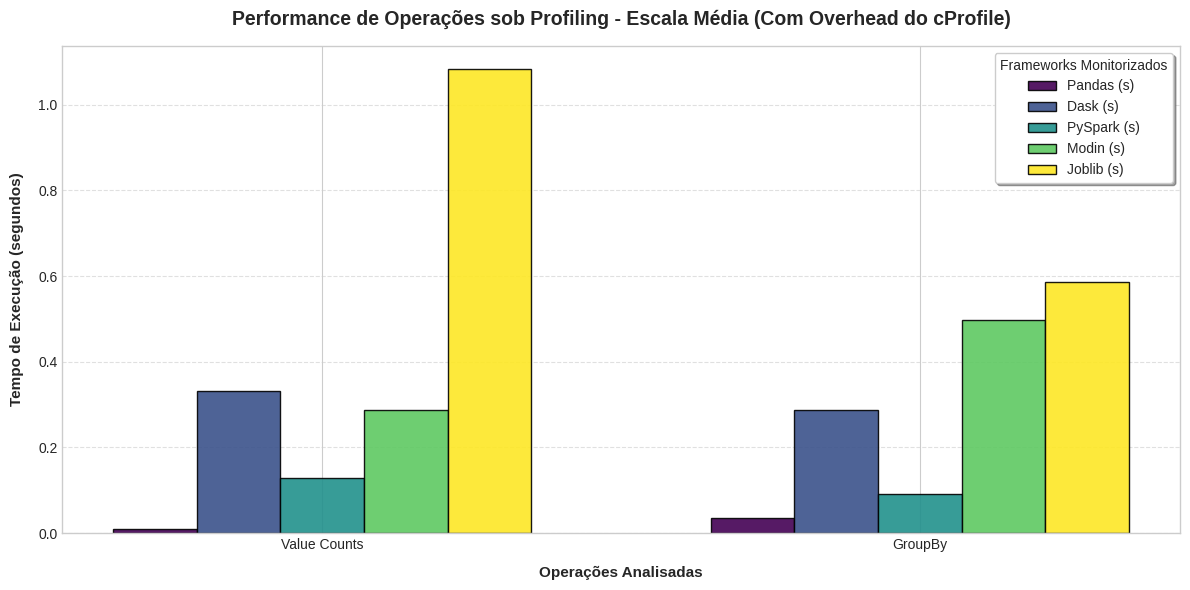

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

if 'ESCALA_DATASET' not in locals():
    ESCALA_DATASET = 1

escala_nome = {1: 'Pequena', 2: 'Média', 3: 'Grande'}.get(ESCALA_DATASET, 'Pequena')

active_profiling = {}
try:
    if 'pandas_results' in locals() and pandas_results:
        active_profiling['Pandas (s)'] = pandas_results
except NameError: pass

try:
    if 'dask_results' in locals() and dask_results:
        active_profiling['Dask (s)'] = dask_results
except NameError: pass

try:
    if 'pyspark_results' in locals() and pyspark_results:
        active_profiling['PySpark (s)'] = pyspark_results
except NameError: pass

try:
    if 'modin_results' in locals() and modin_results:
        active_profiling['Modin (s)'] = modin_results
except NameError: pass

try:
    if 'joblib_results' in locals() and joblib_results:
        active_profiling['Joblib (s)'] = joblib_results
except NameError: pass

if active_profiling:
    prof_df = pd.DataFrame(active_profiling)
    
    print('='*60)
    print(f'  TEMPOS DE EXECUÇÃO SOB PROFILING - ESCALA {escala_nome.upper()}  ')
    print('='*60)
    display(prof_df.round(3))
    
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, ax = plt.subplots(figsize=(12, 6))
    
    import numpy as np
    x = np.arange(len(prof_df))
    cols = prof_df.columns
    width = 0.7 / max(1, len(cols))
    cmap = plt.colormaps.get_cmap('viridis')
    
    for i, col in enumerate(cols):
        color_val = cmap(i / max(1, len(cols) - 1)) if len(cols) > 1 else cmap(0.3)
        offset = (i - (len(cols) - 1) / 2.0) * width
        ax.bar(x + offset, prof_df[col], width, label=col, color=color_val, edgecolor='black', alpha=0.9)
        
    ax.set_xticks(x)
    ax.set_xticklabels(prof_df.index)
    
    plt.title(f'Performance de Operações sob Profiling - Escala {escala_nome} (Com Overhead do cProfile)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Operações Analisadas', fontsize=11, fontweight='bold', labelpad=10)
    plt.ylabel('Tempo de Execução (segundos)', fontsize=11, fontweight='bold', labelpad=10)
    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    
    plt.legend(title='Frameworks Monitorizados', frameon=True, shadow=True, facecolor='white')
    plt.tight_layout()
    
    plt.show()